In [1]:
import pandas as pd
import glob
import os
from functools import reduce

# 1. Update this path to point to your extracted folder!
data_dir = "./GSE343669_RAW" 

# 2. Tell Python to look specifically for the .gz files
file_paths = glob.glob(os.path.join(data_dir, "*.genes.results.gz"))

df_list = []
print(f"Found {len(file_paths)} .gz files. Starting the merge in memory...")

for file in file_paths:
    # Safely extract the sample name (e.g., 'GSM9959599_HPB_KO_2')
    sample_name = os.path.basename(file).split('.')[0]
    
    try:
        # Pandas reads and decompresses the .gz file automatically
        df = pd.read_csv(file, sep='\t', usecols=['gene_id', 'expected_count'])
    except ValueError:
        print(f"Error reading {sample_name}. Columns might be named differently.")
        continue
        
    # Rename 'expected_count' to the actual sample name for the final matrix
    df = df.rename(columns={'expected_count': sample_name})
    
    df_list.append(df)

# 3. Merge all individual DataFrames into one large matrix
master_matrix = reduce(lambda left, right: pd.merge(left, right, on=['gene_id'], how='outer'), df_list)

# 4. Clean up the math for PyDESeq2 (fill empty gaps with 0, round decimals, convert to integers)
master_matrix = master_matrix.fillna(0)
for col in master_matrix.columns:
    if col != 'gene_id':
        master_matrix[col] = master_matrix[col].round().astype(int)

# 5. Export the clean dataset
output_filename = "GSE343669_master_counts.csv"
master_matrix.to_csv(output_filename, index=False)

print(f"Success! Master count matrix saved as {output_filename}")

Found 22 .gz files. Starting the merge in memory...
Success! Master count matrix saved as GSE343669_master_counts.csv


In [2]:
# Create a list of all our sample columns (ignoring the gene_id column)
sample_names = [col for col in master_matrix.columns if col != 'gene_id']

# Build the metadata instructions
metadata = []
for sample in sample_names:
    # 1. Flag the Condition (Wild-Type vs Knockout)
    if "_WT_" in sample:
        condition = "Wild_Type"
    elif "_KO_" in sample:
        condition = "Knockout"
    else:
        condition = "PDX_Xenograft" # The other samples in the dataset
        
    # 2. Flag the Cell Line (MOLT4 vs HPB)
    if "MOLT4" in sample:
        cell_line = "MOLT4"
    elif "HPB" in sample:
        cell_line = "HPB"
    else:
        cell_line = "Patient_Derived"
        
    metadata.append({"Sample": sample, "Condition": condition, "Cell_Line": cell_line})

# Convert it into a clean pandas dataframe and save it
meta_df = pd.DataFrame(metadata)
meta_filename = "GSE343669_metadata.csv"
meta_df.to_csv(meta_filename, index=False)

print(f"Success! Metadata saved as {meta_filename}")
print(meta_df.head(15)) # Prints the first 15 rows so you can verify it

Success! Metadata saved as GSE343669_metadata.csv
                        Sample      Condition        Cell_Line
0   GSM9959582_ETP5-CART28-UNT  PDX_Xenograft  Patient_Derived
1        GSM9959591_MOLT4_WT_3      Wild_Type            MOLT4
2          GSM9959595_HPB_WT_1      Wild_Type              HPB
3          GSM9959584_TH34-UNT  PDX_Xenograft  Patient_Derived
4          GSM9959600_HPB_KO_3       Knockout              HPB
5         GSM9959587_TH67-UNT1  PDX_Xenograft  Patient_Derived
6        GSM9959589_MOLT4_WT_1      Wild_Type            MOLT4
7        GSM9959590_MOLT4_WT_2      Wild_Type            MOLT4
8          GSM9959596_HPB_WT_2      Wild_Type              HPB
9          GSM9959597_HPB_WT_3      Wild_Type              HPB
10         GSM9959598_HPB_KO_1       Knockout              HPB
11       GSM9959592_MOLT4_KO_1       Knockout            MOLT4
12       GSM9959593_MOLT4_KO_2       Knockout            MOLT4
13         GSM9959599_HPB_KO_2       Knockout              HPB
14   

In [3]:
!pip install pydeseq2

  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 38.9 MB/s  0:00:00
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 53.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 7.9 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.3 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 k

In [4]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# 1. ISOLATE THE BIOLOGY: Filter metadata to ONLY the MOLT4 cell line
molt4_meta = meta_df[meta_df['Cell_Line'] == 'MOLT4'].copy()

# PyDESeq2 requires the Sample names to be the index of the dataframe
molt4_meta = molt4_meta.set_index('Sample')

# 2. FILTER THE COUNTS: Match the counts matrix to our selected MOLT4 samples
molt4_counts = master_matrix.set_index('gene_id')
molt4_counts = molt4_counts[molt4_meta.index]

# PyDESeq2 expects a transposed matrix (Samples as rows, Genes as columns)
molt4_counts = molt4_counts.T

print("Starting statistical analysis. This might take a minute...\n")

# 3. INITIALIZE THE MODEL
# We explicitly tell it to use "Condition" as the variable to compare
dds = DeseqDataSet(
    counts=molt4_counts,
    metadata=molt4_meta,
    design_factors="Condition" 
)

# 4. CRUNCH THE NUMBERS
dds.deseq2()

# 5. EXTRACT THE RESULTS
# We set the contrast to compare Knockout vs Wild_Type
stat_res = DeseqStats(dds, contrast=["Condition", "Knockout", "Wild_Type"])
stat_res.summary()

# Save the final statistical results to a dataframe
results_df = stat_res.results_df

# Drop genes that had zero counts across the board to clean it up
results_df = results_df.dropna()

print("\nSuccess! Differential expression calculated.")
print(results_df.head())

Starting statistical analysis. This might take a minute...

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_2028/1371456030.py:21: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 0.79 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 0.82 seconds.

Fitting LFCs...
... done in 0.93 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Condition Knockout vs Wild_Type
                                    baseMean  log2FoldChange     lfcSE  \
gene_id                                                                  
ENSG00000000003.15_TSPAN6           0.000000             NaN       NaN   
ENSG00000000005.6_TNMD              0.000000             NaN       NaN   
ENSG00000000419.14_DPM1          3849.510734        0.190920  0.044150   
ENSG00000000457.14_SCYL3          605.813061       -0.061761  0.086487   
ENSG00000000460.17_C1orf112      2174.671542       -0.204321  0.051478   
...                                      ...             ...       ...   
ENSG00000288721.1_RP5-973N23.5    107.267579       -0.032445  0.239950   
ENSG00000288722.1_F8A1           1165.387090       -0.219924  0.076891   
ENSG00000288723.1_RP11-553N16.6     0.878488        0.644823  2.246292   
ENSG00000288724.1_RP13-546I2.2      0.000000             NaN       NaN   
ENSG00000288725.1_RP11-413H22.3     0.0000

... done in 1.21 seconds.



In [6]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


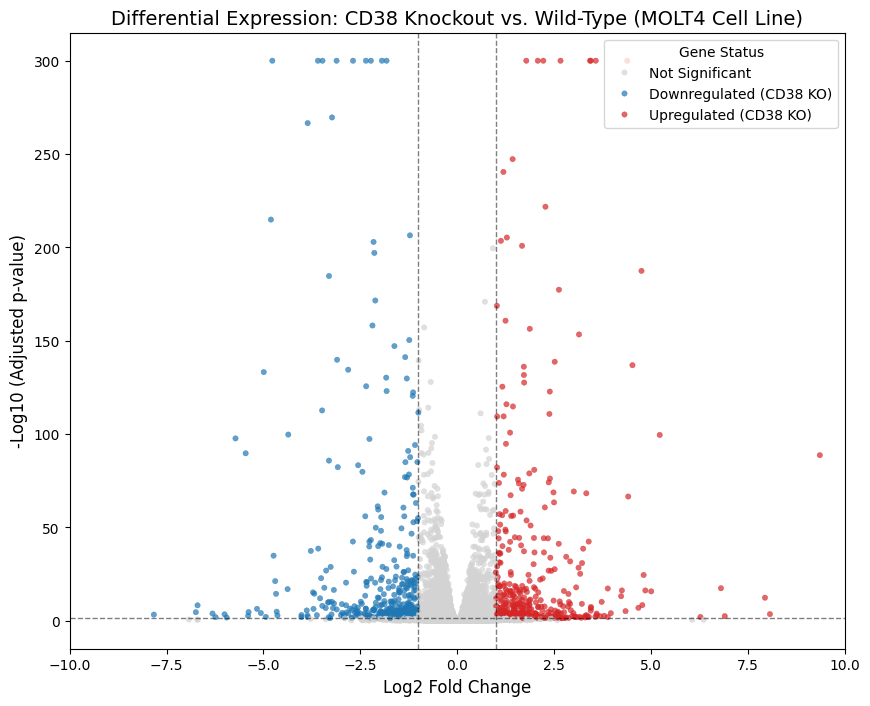

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare the data: drop missing values to avoid math errors
res_plot = results_df.copy()
res_plot = res_plot.dropna(subset=['padj', 'log2FoldChange'])

# Create a column for statistical significance (-log10 of the p-value pushes smaller, more significant numbers higher up on the Y axis)
# We add a tiny number (1e-300) to prevent taking the log of 0
res_plot['nlog10'] = -np.log10(res_plot['padj'] + 1e-300)

# 2. Define our rigorous biological thresholds
padj_cutoff = 0.05
lfc_cutoff = 1.0  # A log2FC of 1 means the gene expression exactly doubled or halved

# 3. Categorize the genes into Upregulated, Downregulated, or Not Significant
def map_color(row):
    if row['padj'] < padj_cutoff and row['log2FoldChange'] > lfc_cutoff:
        return 'Upregulated (CD38 KO)'
    elif row['padj'] < padj_cutoff and row['log2FoldChange'] < -lfc_cutoff:
        return 'Downregulated (CD38 KO)'
    else:
        return 'Not Significant'

res_plot['Status'] = res_plot.apply(map_color, axis=1)

# 4. Draw the Volcano Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=res_plot, 
    x='log2FoldChange', 
    y='nlog10', 
    hue='Status',
    palette={'Upregulated (CD38 KO)': '#d62728', 'Downregulated (CD38 KO)': '#1f77b4', 'Not Significant': '#d3d3d3'},
    s=15, 
    alpha=0.7,
    edgecolor=None
)

# Add the threshold lines
plt.axhline(-np.log10(padj_cutoff), color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(lfc_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(-lfc_cutoff, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Clean up the aesthetics
plt.title('Differential Expression: CD38 Knockout vs. Wild-Type (MOLT4 Cell Line)', fontsize=14)
plt.xlabel('Log2 Fold Change', fontsize=12)
plt.ylabel('-Log10 (Adjusted p-value)', fontsize=12)
plt.xlim(-10, 10) # Zoom in to ignore extreme outliers
plt.legend(title='Gene Status')

# Save the high-res image to your folder!
plt.savefig('CD38_Volcano_Plot.png', dpi=300, bbox_inches='tight')
plt.show()